## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-1st_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-01,2023,5,2023-04-30,39.662866,22.635299,0.320605,0.010753,-0.297699,-0.010753,0.505039,0.205061,-0.442851,-0.205061,0.125752,0.119283,0.096853,0.119283,2023-05-01,39.662866,22.635299,14966.0,14353.0,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-05-01,39.650181,22.650104,70.551421,2023-04-24,2023-04-17,2023-04-24,2023-04-17,0.462882,28.530567
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-01,2023,5,2023-04-30,39.752697,22.707165,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,2023-05-01,39.752697,22.707165,14569.0,14025.0,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-01,2023,5,2023-04-30,39.788630,22.729622,0.398340,-0.021568,-0.405003,0.021568,0.148230,0.267161,-0.058763,-0.267161,0.041401,0.077481,0.012572,0.077481,2023-05-01,39.788630,22.729622,14419.0,13927.0,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-05-01,2023,5,2023-04-30,39.662866,22.779030,0.659985,0.255662,-0.558361,-0.255662,0.666750,0.288541,-0.556839,-0.288541,0.021385,0.034793,0.019709,0.034793,2023-05-01,39.662866,22.779030,14859.0,14292.0,39.662866,22.779030,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,2023-05-01,39.650181,22.750104,76.251762,2023-04-24,2023-04-17,2023-04-24,2023-04-17,4.479433,30.095222
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-05-01,2023,5,2023-04-30,39.698798,22.779030,0.510698,0.199188,-0.470016,-0.199188,0.579717,0.203453,-0.511025,-0.203453,0.036495,0.035902,0.025967,0.035902,2023-05-01,39.698798,22.779030,14881.0,14298.0,39.698798,22.779030,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,2023-05-01,39.750182,22.750104,80.850409,2023-04-24,2023-04-17,2023-04-24,2023-04-17,2.064366,13.038493


In [6]:
#wnv_file.head()

In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-05-01,2023,5,0.320605,0.010753,-0.297699,-0.010753,0.505039,0.205061,-0.442851,-0.205061,0.125752,0.119283,0.096853,0.119283,14966.0,14353.0,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,70.551421,0.462882,28.530567
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-05-01,2023,5,0.506922,0.087536,-0.458373,-0.087536,0.521654,0.109084,-0.459319,-0.109084,0.056933,0.073780,0.034842,0.073780,14569.0,14025.0,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,80.850409,2.064366,13.038493
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-05-01,2023,5,0.398340,-0.021568,-0.405003,0.021568,0.148230,0.267161,-0.058763,-0.267161,0.041401,0.077481,0.012572,0.077481,14419.0,13927.0,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,80.850409,2.064366,13.038493
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-05-01,2023,5,0.659985,0.255662,-0.558361,-0.255662,0.666750,0.288541,-0.556839,-0.288541,0.021385,0.034793,0.019709,0.034793,14859.0,14292.0,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,76.251762,4.479433,30.095222
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-05-01,2023,5,0.510698,0.199188,-0.470016,-0.199188,0.579717,0.203453,-0.511025,-0.203453,0.036495,0.035902,0.025967,0.035902,14881.0,14298.0,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,80.850409,2.064366,13.038493


In [11]:
#wnv_file.head(5)

In [12]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [13]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [14]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [15]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [16]:
# merged

In [17]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [18]:
merged['case'].value_counts()

0    126
Name: case, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [20]:
dataset = grouped.mean()

In [21]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-05-01,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,5.0,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14608.285714,14153.000000,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,76.675988,2.381410,17.837466,0.0
1,2023-05-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,5.0,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,14633.444444,14200.333333,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,208.946587,3.480882,69.269711,0.0
2,2023-05-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,5.0,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14533.000000,14299.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,163.677945,7.946645,55.220344,0.0
3,2023-05-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,5.0,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14526.000000,13953.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,141.474393,8.412601,10.754827,0.0
4,2023-05-01,βολου,θεσσαλιας,22.883800,39.351977,2023.0,5.0,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,14920.000000,14251.333333,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,146.622452,1.161971,49.566698,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-05-01,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,5.0,0.480148,0.146282,-0.406046,-0.146282,0.482391,0.136832,-0.414499,-0.136832,0.056086,0.063591,0.039908,0.063591,14615.200000,14143.000000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,58.330156,1.604215,14.232823,0.0
21,2023-05-01,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,5.0,0.549746,0.172030,-0.490626,-0.172030,0.581852,0.193943,-0.505295,-0.193943,0.065187,0.075038,0.041146,0.075038,14875.600000,14030.200000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,136.919840,6.316782,12.798308,0.0
22,2023-05-01,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,5.0,0.535068,0.234040,-0.454530,-0.234040,0.550848,0.197866,-0.473108,-0.197866,0.062092,0.064908,0.048927,0.064908,14770.750000,14176.750000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,51.931327,1.330120,15.736819,0.0
23,2023-05-01,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,5.0,0.476323,0.093934,-0.445219,-0.093934,0.511657,0.142931,-0.466496,-0.142931,0.079564,0.078632,0.046201,0.078632,14845.333333,14292.333333,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,94.381480,5.099200,21.808518,0.0


In [22]:
dataset = dataset.astype({'case': 'int'})

In [23]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [24]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [25]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [27]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-05-01,αγιας,θεσσαλιας,22.75027,39.71097,2023,5,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14608.285714,14153.000000,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,76.675988,2.381410,17.837466,0,1,18,45.76610,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
1,2023-05-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2023,5,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,14633.444444,14200.333333,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,208.946587,3.480882,69.269711,0,1,18,45.23937,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
2,2023-05-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2023,5,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14533.000000,14299.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,163.677945,7.946645,55.220344,0,1,18,46.11198,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
3,2023-05-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2023,5,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14526.000000,13953.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,141.474393,8.412601,10.754827,0,1,18,44.69433,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
4,2023-05-01,βολου,θεσσαλιας,22.88380,39.35198,2023,5,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,14920.000000,14251.333333,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,146.622452,1.161971,49.566698,0,1,18,45.52194,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-05-01,τεμπων,θεσσαλιας,22.55316,39.85211,2023,5,0.480148,0.146282,-0.406046,-0.146282,0.482391,0.136832,-0.414499,-0.136832,0.056086,0.063591,0.039908,0.063591,14615.200000,14143.000000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,58.330156,1.604215,14.232823,0,1,18,45.79122,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
21,2023-05-01,τρικκαιων,θεσσαλιας,21.79756,39.63506,2023,5,0.549746,0.172030,-0.490626,-0.172030,0.581852,0.193943,-0.505295,-0.193943,0.065187,0.075038,0.041146,0.075038,14875.600000,14030.200000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,136.919840,6.316782,12.798308,0,1,18,45.23352,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
22,2023-05-01,τυρναβου,θεσσαλιας,22.34300,39.82847,2023,5,0.535068,0.234040,-0.454530,-0.234040,0.550848,0.197866,-0.473108,-0.197866,0.062092,0.064908,0.048927,0.064908,14770.750000,14176.750000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,51.931327,1.330120,15.736819,0,1,18,45.66746,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823
23,2023-05-01,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2023,5,0.476323,0.093934,-0.445219,-0.093934,0.511657,0.142931,-0.466496,-0.142931,0.079564,0.078632,0.046201,0.078632,14845.333333,14292.333333,14179.025000,13814.481685,14325.770833,13813

<AxesSubplot:>

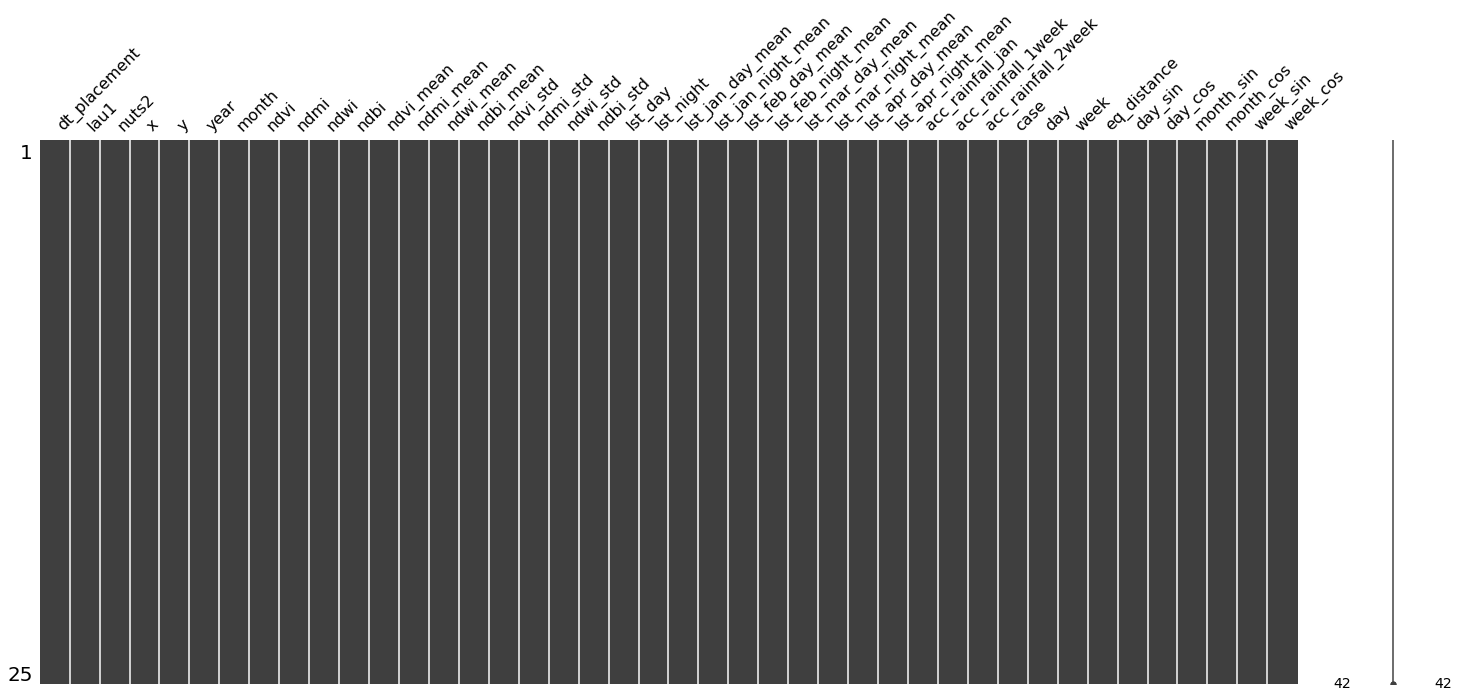

In [28]:
missingno.matrix(dataset)

In [29]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [30]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [31]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [32]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [33]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [34]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['καλαμπακας', 'λαρισαιων', 'ρηγα φερραιου', 'φαρκαδονας']

Length: 4


In [35]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ρηγα φεραιου','ρηγα φερραιου'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [36]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [37]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

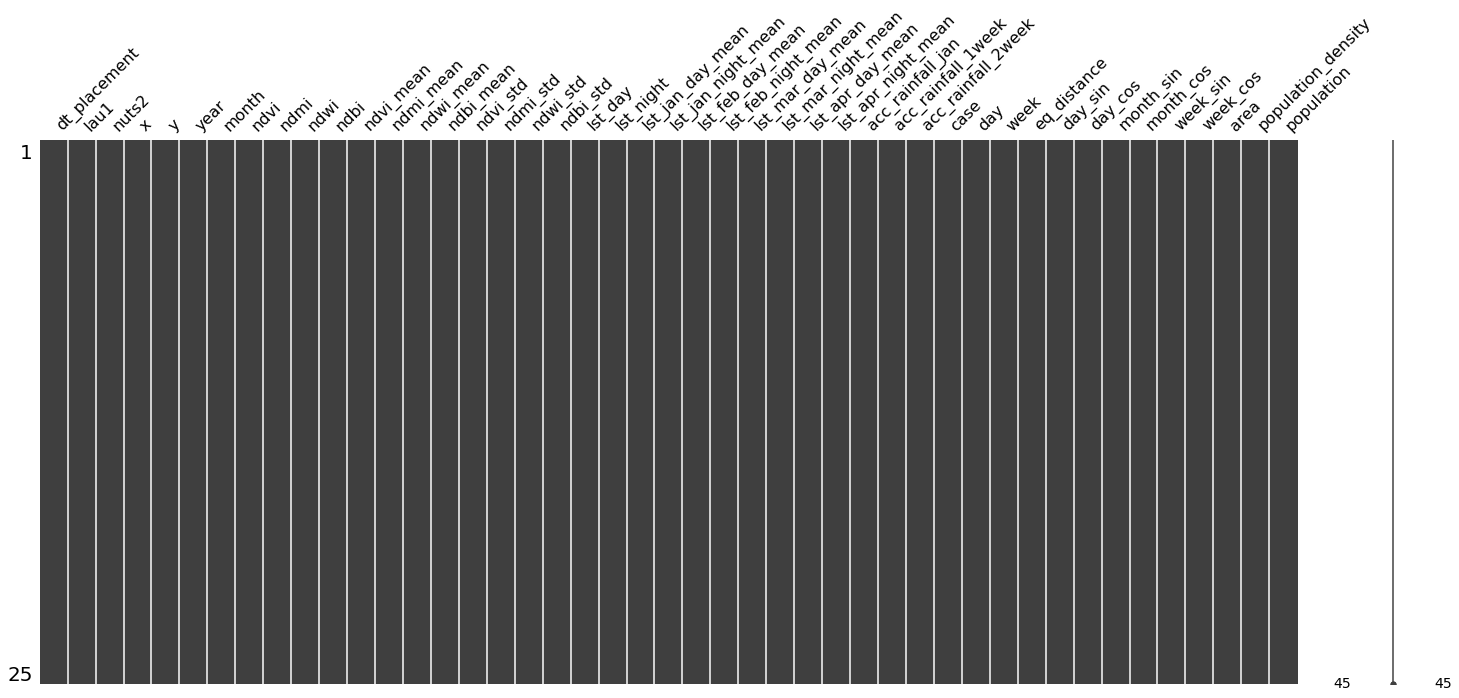

In [38]:
missingno.matrix(dataset)

In [39]:
missing = describe_dataframe(dataset)

In [40]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2023-05-01,αγιας,θεσσαλιας,22.75027,39.71097,2023,5,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14608.285714,14153.000000,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,76.675988,2.381410,17.837466,0,1,18,45.76610,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,661.8,17.3,10705.00
1,2023-05-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2023,5,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,14633.444444,14200.333333,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,208.946587,3.480882,69.269711,0,1,18,45.23937,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,905.4,20.6,16004.00
2,2023-05-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2023,5,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14533.000000,14299.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,163.677945,7.946645,55.220344,0,1,18,46.11198,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,129.6,21.2,3153.00
3,2023-05-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2023,5,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14526.000000,13953.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,141.474393,8.412601,10.754827,0,1,18,44.69433,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,372.9,9.3,3515.00
4,2023-05-01,βολου,θεσσαλιας,22.88380,39.35198,2023,5,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,14920.000000,14251.333333,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,146.622452,1.161971,49.566698,0,1,18,45.52194,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-05-01,τεμπων,θεσσαλιας,22.55316,39.85211,2023,5,0.480148,0.146282,-0.406046,-0.146282,0.482391,0.136832,-0.414499,-0.136832,0.056086,0.063591,0.039908,0.063591,14615.200000,14143.000000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,58.330156,1.604215,14.232823,0,1,18,45.79122,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,576.7,23.8,11.99
21,2023-05-01,τρικκαιων,θεσσαλιας,21.79756,39.63506,2023,5,0.549746,0.172030,-0.490626,-0.172030,0.581852,0.193943,-0.505295,-0.193943,0.065187,0.075038,0.041146,0.075038,14875.600000,14030.200000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,136.919840,6.316782,12.798308,0,1,18,45.23352,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,607.6,133.9,78508.00
22,2023-05-01,τυρναβου,θεσσαλιας,22.34300,39.82847,2023,5,0.535068,0.234040,-0.454530,-0.234040,0.550848,0.197866,-0.473108,-0.197866,0.062092,0.064908,0.048927,0.064908,14770.750000,14176.750000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,51.931327,1.330120,15.736819,0,1,18,45.66746,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,525.3,47.7,22252.00
23,2023-05-01,φαρκαδονας,θεσσαλιας,22.

In [41]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-1st.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-05-01,19
1,22.692366,39.136391,2023-05-01,4
2,24.073790,39.328960,2023-05-01,1
3,21.430513,39.221380,2023-05-01,18
4,22.883800,39.351977,2023-05-01,68
...,...,...,...,...
20,22.553160,39.852112,2023-05-01,32
21,21.797560,39.635058,2023-05-01,29
22,22.343000,39.828472,2023-05-01,29
23,22.020557,39.603750,2023-05-01,51


In [42]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [43]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [44]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0008571819480130482


In [45]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [46]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [47]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [48]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2023-05-01,αγιας,θεσσαλιας,22.75027,39.71097,2023,5,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14608.285714,14153.000000,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,76.675988,2.381410,17.837466,0,1,18,45.76610,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,661.8,17.3,10705.0,19
1,2023-05-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2023,5,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,14633.444444,14200.333333,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,208.946587,3.480882,69.269711,0,1,18,45.23937,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,905.4,20.6,16004.0,4
2,2023-05-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2023,5,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,14533.000000,14299.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,163.677945,7.946645,55.220344,0,1,18,46.11198,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,129.6,21.2,3153.0,1
3,2023-05-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2023,5,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,14526.000000,13953.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,141.474393,8.412601,10.754827,0,1,18,44.69433,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,372.9,9.3,3515.0,18
4,2023-05-01,βολου,θεσσαλιας,22.88380,39.35198,2023,5,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,14920.000000,14251.333333,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,146.622452,1.161971,49.566698,0,1,18,45.52194,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,385.6,374.6,138865.0,68


<AxesSubplot:>

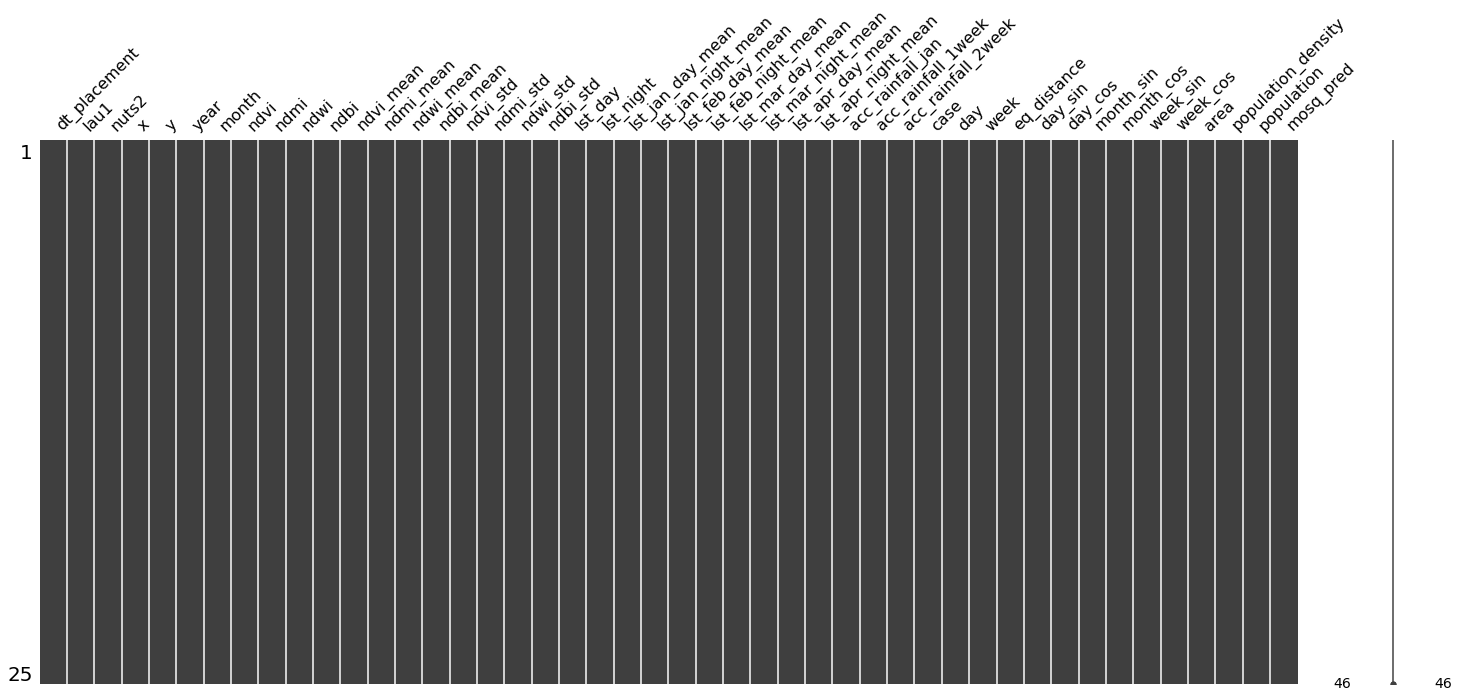

In [49]:
missingno.matrix(dataset)

In [50]:
dataset.reset_index(inplace=True, drop=True)

In [51]:
dataset = calculate_mosq_previous(dataset)

In [52]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

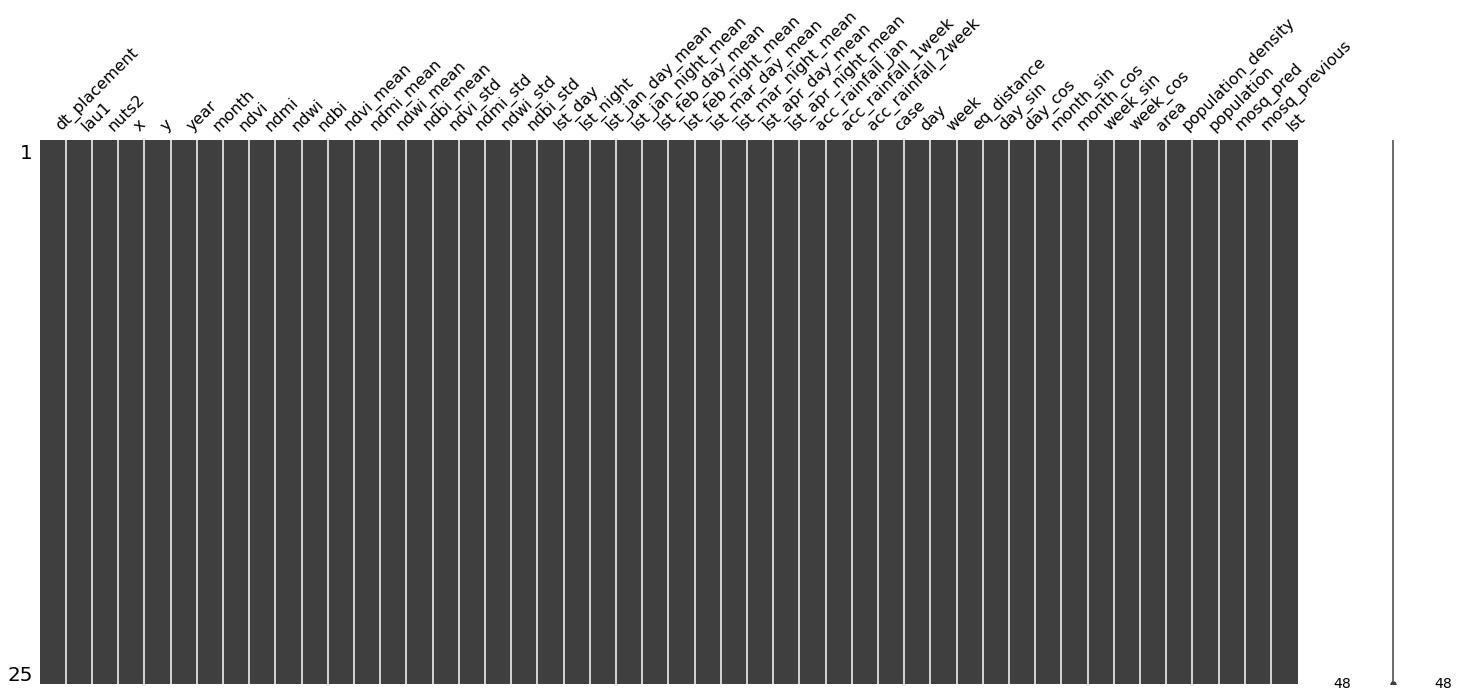

In [53]:
missingno.matrix(dataset)

In [54]:
dataset['case'].value_counts()

0    25
Name: case, dtype: int64

In [55]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [56]:
dataset = convert_multiple_cases(dataset)

In [57]:
dataset['case'].value_counts()

0    25
Name: case, dtype: int64

In [58]:
cols = dataset.columns

In [59]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [60]:
len(cols)

48

In [61]:
# check columns

In [62]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [63]:
len(final_columns)

48

In [64]:
dataset_final = dataset[final_columns].copy()

In [65]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2023-05-01,θεσσαλιας,αγιας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,661.8,10705.00,17.3,45.76610,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14.462857,19.015714,9.910000,10.014591,3.062158,9.497627,2.252233,16.518764,4.850248,17.420808,6.992874,2.381410,17.837466,76.675988,19,0,0
1,22.69237,39.13639,2023-05-01,θεσσαλιας,αλμυρου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,905.4,16004.00,20.6,45.23937,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,15.187778,19.518889,10.856667,11.574271,4.271414,11.566611,3.165456,16.910796,6.859971,19.659042,8.292132,3.480882,69.269711,208.946587,4,0,0
2,24.07379,39.32896,2023-05-01,θεσσαλιας,αλοννησου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,129.6,3153.00,21.2,46.11198,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,15.170000,17.510000,12.830000,12.912222,9.263333,11.806000,8.335714,15.332667,9.731333,17.710000,11.163333,7.946645,55.220344,163.677945,1,0,0
3,21.43051,39.22138,2023-05-01,θεσσαλιας,αργιθεας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,372.9,3515.00,9.3,44.69433,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,11.640000,17.370000,5.910000,6.545931,2.202813,6.295806,-1.524472,12.140821,3.852222,13.211548,4.210667,8.412601,10.754827,141.474393,18,0,0
4,22.88380,39.35198,2023-05-01,θεσσαλιας,βολου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,385.6,138865.00,374.6,45.52194,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,18.563333,25.250000,11.876667,13.062496,4.339126,13.258730,3.548556,18.642628,6.426410,21.021667,8.192857,1.161971,49.566698,146.622452,68,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,22.55316,39.85211,2023-05-01,θεσσαλιας,τεμπων,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,576.7,11.99,23.8,45.79122,0.480148,0.146282,-0.406046,-0.146282,0.482391,0.136832,-0.414499,-0.136832,0.056086,0.063591,0.039908,0.063591,14.432000,19.154000,9.710000,9.486897,2.246400,9.153402,1.055296,15.363382,4.702971,16.772958,6.591786,1.604215,14.232823,58.330156,32,0,0
21,21.79756,39.63506,2023-05-01,θεσσαλιας,τρικκαιων,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,607.6,78508.00,133.9,45.23352,0.549746,0.172030,-0.490626,-0.172030,0.581852,0.193943,-0.505295,-0.193943,0.065187,0.075038,0.041146,0.075038,15.908000,24.362000,7.454000,10.673662,2.566048,13.918486,2.152524,19.277797,6.588566,20.641230,7.794762,6.316782,12.798308,136.919840,29,0,0
22,22.34300,39.82847,2023-05-01,θεσσαλιας,τυρναβου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,525.3,22252.00,47.7,45.66746,0.535068,0.234040,-0.454530,-0.234040,0.550848,0.197866,-0.473108,-0.197866,0.062092,0.064908,0.048927,0.064908,16.325000,22.265000,10.385000,10.962639,1.977582,11.857741,1.268813,18.244189,5.305865,20.608426,7.695605,1.330120,15.736819,51.931327,29,0,0
23,22.02056,39.60375,2023-05-01,θεσσαλιας,φαρκαδονας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,368.7,11348.00,36.3,45.31404,0.476323,0.0939

In [66]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-1st.csv", encoding = enc, index = False)